In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
prepared_file_path = r"D:\Data Analytics Project\EduPro_Predictive_Modeling\data\prepared_data\EduPro_Prepared.xlsx"

In [3]:
df = pd.read_excel(
    prepared_file_path,
    sheet_name="Prepared_Data"
)

In [4]:
df.shape

(10000, 29)

In [5]:
df.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,UserName,UserAge,UserGender,...,TeacherAge,TeacherGender,Expertise,YearsOfExperience,TeacherRating,TransactionYear,TransactionMonth,TransactionDay,TransactionDayOfWeek,TransactionQuarter
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,morrisonamanda,33,Female,...,49,Male,Cybersecurity,24,4.58,2025,10,25,5,4
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,morrisonamanda,33,Female,...,49,Male,Cybersecurity,24,4.58,2025,1,13,0,1
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,morrisonamanda,33,Female,...,49,Male,Cybersecurity,24,4.58,2025,3,28,4,1
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,fthornton,23,Female,...,49,Male,Cybersecurity,24,4.58,2025,6,2,0,2
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,fthornton,23,Female,...,49,Female,Machine Learning,21,4.97,2025,8,10,6,3


In [6]:
df.columns.tolist()

['TransactionID',
 'UserID',
 'CourseID',
 'TransactionDate',
 'Amount',
 'PaymentMethod',
 'TeacherID',
 'UserName',
 'UserAge',
 'UserGender',
 'Email',
 'CourseName',
 'CourseCategory',
 'CourseType',
 'CourseLevel',
 'CoursePrice',
 'CourseDuration',
 'CourseRating',
 'TeacherName',
 'TeacherAge',
 'TeacherGender',
 'Expertise',
 'YearsOfExperience',
 'TeacherRating',
 'TransactionYear',
 'TransactionMonth',
 'TransactionDay',
 'TransactionDayOfWeek',
 'TransactionQuarter']

## Verify the dataset before EDA

In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Rows: 10000
Columns: 29
Missing values: 0
Duplicate rows: 0


## Create the course-level dataset

In [8]:
course_columns = [
    "CourseID",
    "CourseName",
    "CourseCategory",
    "CourseType",
    "CourseLevel",
    "CoursePrice",
    "CourseDuration",
    "CourseRating"
]

In [9]:
courses_eda = df[course_columns].drop_duplicates(
    subset="CourseID"
).copy()

In [10]:
courses_eda.shape

(60, 8)

In [11]:
courses_eda.head()

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,CR00016,Digital Marketing,Marketing,Free,Intermediate,0.0,42.68,4.72
1,CR00037,Scrum Essentials,Project Management,Free,Intermediate,0.0,33.93,3.45
2,CR00019,Content Marketing,Marketing,Free,Advanced,0.0,18.00,2.98
3,CR00048,AI Ethics,Artificial Intelligence,Free,Beginner,0.0,42.70,3.64
4,CR00060,Content Creation,Digital Marketing,Free,Beginner,0.0,8.95,2.14


## Calculate Enrollment Count 

In [12]:
enrollment_counts = (
    df.groupby("CourseID")
      .size()
      .reset_index(name="EnrollmentCount")
)

In [13]:
enrollment_counts.head()

,CourseID,EnrollmentCount
0,CR00001,164
1,CR00002,149
2,CR00003,173
3,CR00004,154
4,CR00005,166


In [14]:
courses_eda = courses_eda.merge(
    enrollment_counts,
    on="CourseID",
    how="left"
)

## Calculate Course Revenue

In [15]:
course_revenue = (
    df.groupby("CourseID")["Amount"]
      .sum()
      .reset_index(name="CourseRevenue")
)

In [16]:
courses_eda = courses_eda.merge(
    course_revenue,
    on="CourseID",
    how="left"
)

In [17]:
courses_eda.head()

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,EnrollmentCount,CourseRevenue
0,CR00016,Digital Marketing,Marketing,Free,Intermediate,0.0,42.68,4.72,153,0.0
1,CR00037,Scrum Essentials,Project Management,Free,Intermediate,0.0,33.93,3.45,153,0.0
2,CR00019,Content Marketing,Marketing,Free,Advanced,0.0,18.00,2.98,177,0.0
3,CR00048,AI Ethics,Artificial Intelligence,Free,Beginner,0.0,42.70,3.64,186,0.0
4,CR00060,Content Creation,Digital Marketing,Free,Beginner,0.0,8.95,2.14,165,0.0


## Final Course-level validation

In [18]:
print("Course-level rows:", courses_eda.shape[0])
print("Course-level columns:", courses_eda.shape[1])

Course-level rows: 60
Course-level columns: 10


In [19]:
courses_eda.isnull().sum()

CourseID           0
CourseName         0
CourseCategory     0
CourseType         0
CourseLevel        0
CoursePrice        0
CourseDuration     0
CourseRating       0
EnrollmentCount    0
CourseRevenue      0
dtype: int64

In [20]:
courses_eda.duplicated(subset="CourseID").sum()

np.int64(0)

In [21]:
courses_eda["CourseID"].nunique()

60

## Basic Statistical Summary

In [22]:
courses_eda.describe()

,CoursePrice,CourseDuration,CourseRating,EnrollmentCount,CourseRevenue
count,60.000000,60.000000,60.000000,60.000000,60.000000
mean,92.986333,27.632500,3.097833,166.666667,15188.724500
std,153.601506,16.092578,1.171232,12.523424,25409.721911
min,0.000000,1.200000,1.130000,140.000000,0.000000
25%,0.000000,14.500000,2.107500,157.500000,0.000000
50%,0.000000,28.505000,3.065000,166.000000,0.000000
75%,133.615000,43.012500,4.102500,174.750000,20858.060000
max,490.900000,49.730000,4.940000,196.000000,85416.600000


In [23]:
courses_eda[
    [
        "CoursePrice",
        "CourseDuration",
        "CourseRating",
        "EnrollmentCount",
        "CourseRevenue"
    ]
].describe()

,CoursePrice,CourseDuration,CourseRating,EnrollmentCount,CourseRevenue
count,60.000000,60.000000,60.000000,60.000000,60.000000
mean,92.986333,27.632500,3.097833,166.666667,15188.724500
std,153.601506,16.092578,1.171232,12.523424,25409.721911
min,0.000000,1.200000,1.130000,140.000000,0.000000
25%,0.000000,14.500000,2.107500,157.500000,0.000000
50%,0.000000,28.505000,3.065000,166.000000,0.000000
75%,133.615000,43.012500,4.102500,174.750000,20858.060000
max,490.900000,49.730000,4.940000,196.000000,85416.600000


## Course Cateogory Analysis

In [24]:
courses_eda["CourseCategory"].value_counts()

CourseCategory
Marketing                  5
Project Management         5
Artificial Intelligence    5
Digital Marketing          5
Finance                    5
Data Science               5
Programming                5
Cybersecurity              5
Machine Learning           5
Design                     5
Business                   5
Web Development            5
Name: count, dtype: int64

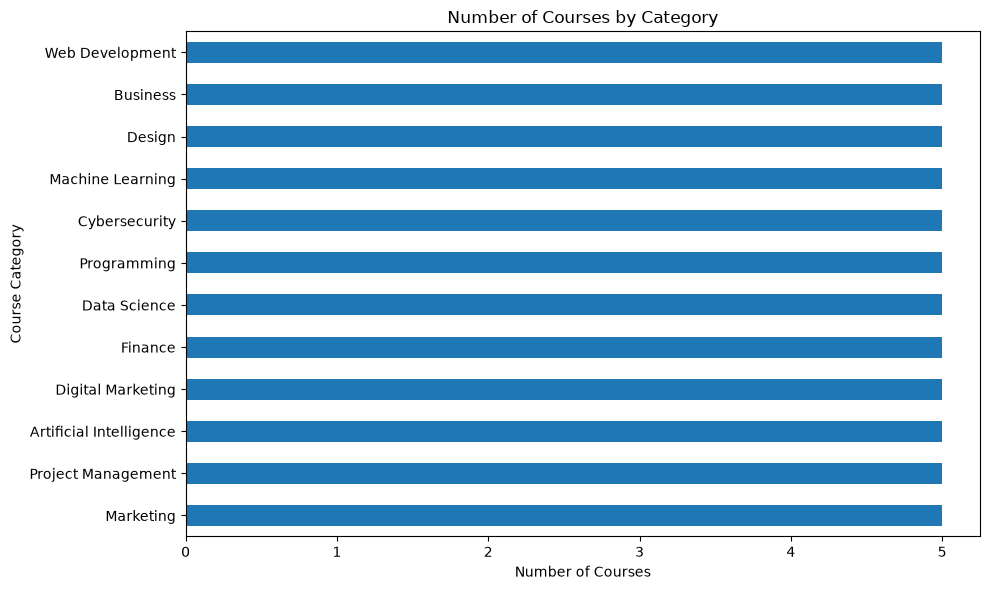

In [25]:
category_counts = (
    courses_eda["CourseCategory"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

category_counts.plot(kind="barh")

plt.title("Number of Courses by Category")
plt.xlabel("Number of Courses")
plt.ylabel("Course Category")
plt.tight_layout()
plt.show()

## Category-wise enrollment demand

In [26]:
category_demand = (
    courses_eda.groupby("CourseCategory")["EnrollmentCount"]
    .sum()
    .sort_values(ascending=False)
)

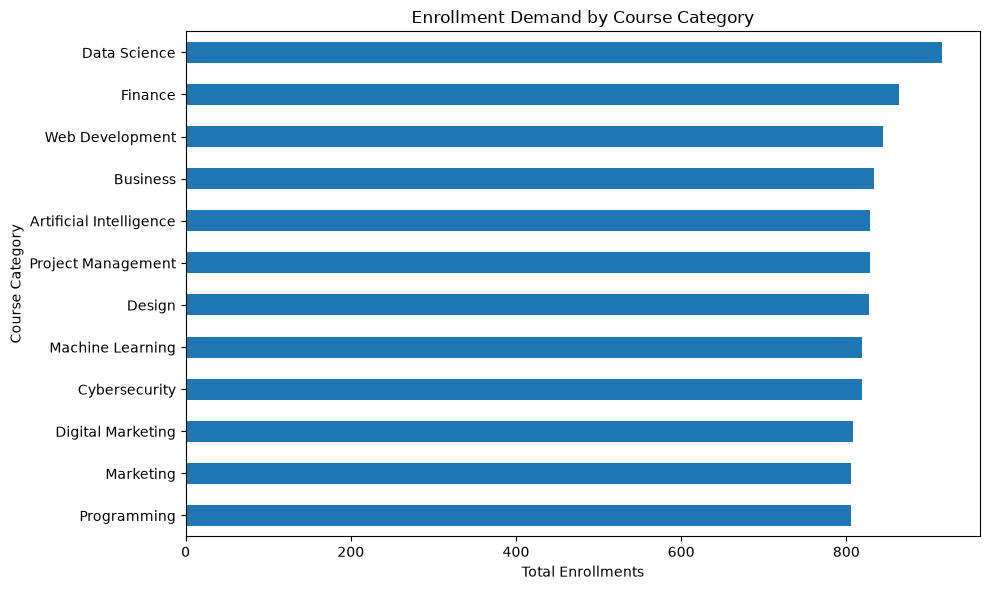

In [27]:
plt.figure(figsize=(10, 6))

category_demand.sort_values().plot(kind="barh")

plt.title("Enrollment Demand by Course Category")
plt.xlabel("Total Enrollments")
plt.ylabel("Course Category")
plt.tight_layout()
plt.show()

## Categorey-wise revenue

In [28]:
category_revenue = (
    courses_eda.groupby("CourseCategory")["CourseRevenue"]
    .sum()
    .sort_values(ascending=False)
)

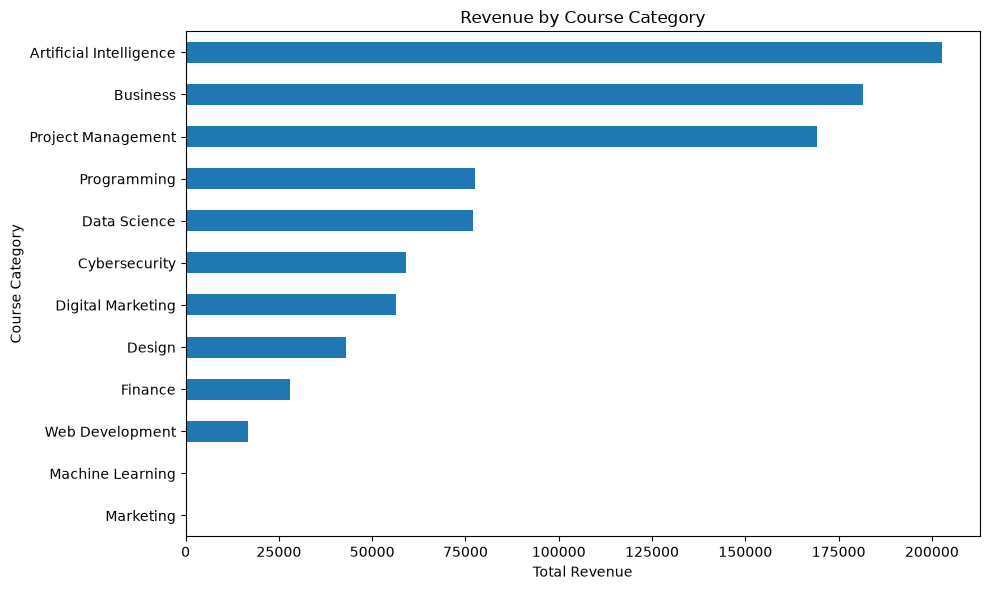

In [29]:
plt.figure(figsize=(10, 6))

category_revenue.sort_values().plot(kind="barh")

plt.title("Revenue by Course Category")
plt.xlabel("Total Revenue")
plt.ylabel("Course Category")
plt.tight_layout()
plt.show()

## Course Type analysis

In [30]:
courses_eda["CourseType"].value_counts()

CourseType
Free    38
Paid    22
Name: count, dtype: int64

In [31]:
type_demand = (
    courses_eda.groupby("CourseType")["EnrollmentCount"]
    .sum()
    .sort_values(ascending=False)
)

print(type_demand)

CourseType
Free    6403
Paid    3597
Name: EnrollmentCount, dtype: int64


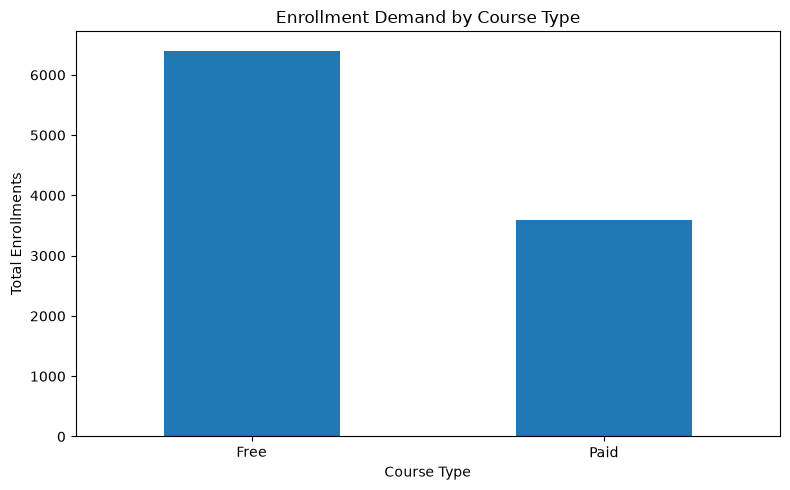

In [32]:
plt.figure(figsize=(8, 5))

type_demand.plot(kind="bar")

plt.title("Enrollment Demand by Course Type")
plt.xlabel("Course Type")
plt.ylabel("Total Enrollments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Course Level analysis

In [33]:
courses_eda["CourseLevel"].value_counts()

CourseLevel
Advanced        21
Beginner        21
Intermediate    18
Name: count, dtype: int64

In [34]:
level_demand = (
    courses_eda.groupby("CourseLevel")["EnrollmentCount"]
    .sum()
    .sort_values(ascending=False)
)

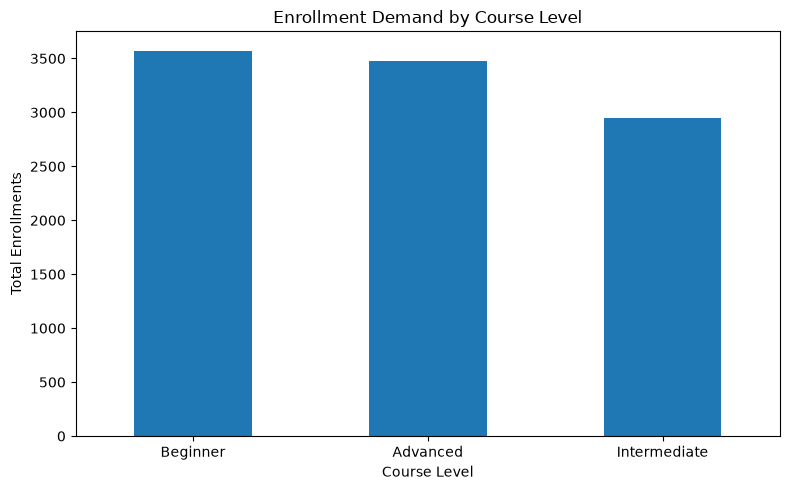

In [35]:
plt.figure(figsize=(8, 5))

level_demand.plot(kind="bar")

plt.title("Enrollment Demand by Course Level")
plt.xlabel("Course Level")
plt.ylabel("Total Enrollments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
level_revenue = (
    courses_eda.groupby("CourseLevel")["CourseRevenue"]
    .sum()
    .sort_values(ascending=False)
)

print(level_revenue)

CourseLevel
Beginner        369021.38
Advanced        278036.18
Intermediate    264265.91
Name: CourseRevenue, dtype: float64


## Top 10 Courses by Enrollment

In [37]:
top_courses_enrollment = (
    courses_eda
    .sort_values("EnrollmentCount", ascending=False)
    .head(10)
)

In [38]:
top_courses_enrollment[
    [
        "CourseID",
        "CourseName",
        "CourseCategory",
        "CourseType",
        "CourseLevel",
        "CoursePrice",
        "CourseRating",
        "EnrollmentCount"
    ]
]

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseRating,EnrollmentCount
19,CR00021,Data Analysis with Python,Data Science,Free,Intermediate,0.00,3.60,196
25,CR00058,Social Media Strategy,Digital Marketing,Free,Beginner,0.00,4.44,194
7,CR00025,Statistical Analysis,Data Science,Paid,Beginner,299.57,3.74,192
3,CR00048,AI Ethics,Artificial Intelligence,Free,Beginner,0.00,3.64,186
35,CR00023,Machine Learning Fundamentals,Data Science,Free,Intermediate,0.00,3.02,185
5,CR00042,Investment Strategies,Finance,Free,Intermediate,0.00,4.10,183
21,CR00043,Corporate Finance,Finance,Free,Beginner,0.00,4.14,182
18,CR00010,3D Modeling,Design,Free,Advanced,0.00,4.45,180
23,CR00035,Cyber Threat Intelligence,Cybersecurity,Free,Beginner,0.00,4.94,179
37,CR00007,UI/UX Design,Design,Free,Advanced,0.00,2.61,178


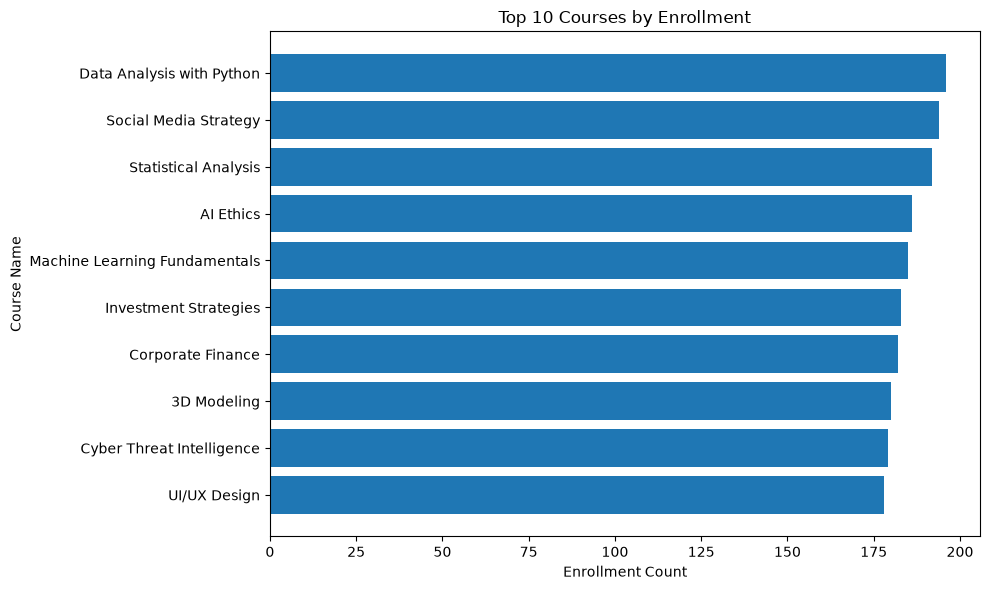

In [39]:
top10 = top_courses_enrollment.sort_values(
    "EnrollmentCount"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["CourseName"],
    top10["EnrollmentCount"]
)

plt.title("Top 10 Courses by Enrollment")
plt.xlabel("Enrollment Count")
plt.ylabel("Course Name")
plt.tight_layout()
plt.show()

## Top 10 Courses by Revenue

In [40]:
top_courses_revenue = (
    courses_eda
    .sort_values("CourseRevenue", ascending=False)
    .head(10)
)

In [41]:
top_courses_revenue[
    [
        "CourseID",
        "CourseName",
        "CourseCategory",
        "CoursePrice",
        "CourseRating",
        "EnrollmentCount",
        "CourseRevenue"
    ]
]

,CourseID,CourseName,CourseCategory,CoursePrice,CourseRating,EnrollmentCount,CourseRevenue
40,CR00050,Computer Vision,Artificial Intelligence,490.90,4.55,174,85416.60
45,CR00012,Business Strategy,Business,487.92,3.64,173,84410.16
16,CR00001,Python Basics,Programming,472.28,4.74,164,77453.92
48,CR00049,Deep Learning,Artificial Intelligence,415.51,3.11,163,67728.13
52,CR00034,Data Encryption,Cybersecurity,394.26,1.35,150,59139.00
55,CR00039,Project Planning,Project Management,346.71,1.23,167,57900.57
7,CR00025,Statistical Analysis,Data Science,299.57,3.74,192,57517.44
14,CR00040,Leadership in Projects,Project Management,327.99,1.51,174,57070.26
58,CR00038,Risk Management,Project Management,342.61,4.84,158,54132.38
46,CR00011,Entrepreneurship 101,Business,326.02,2.69,151,49229.02


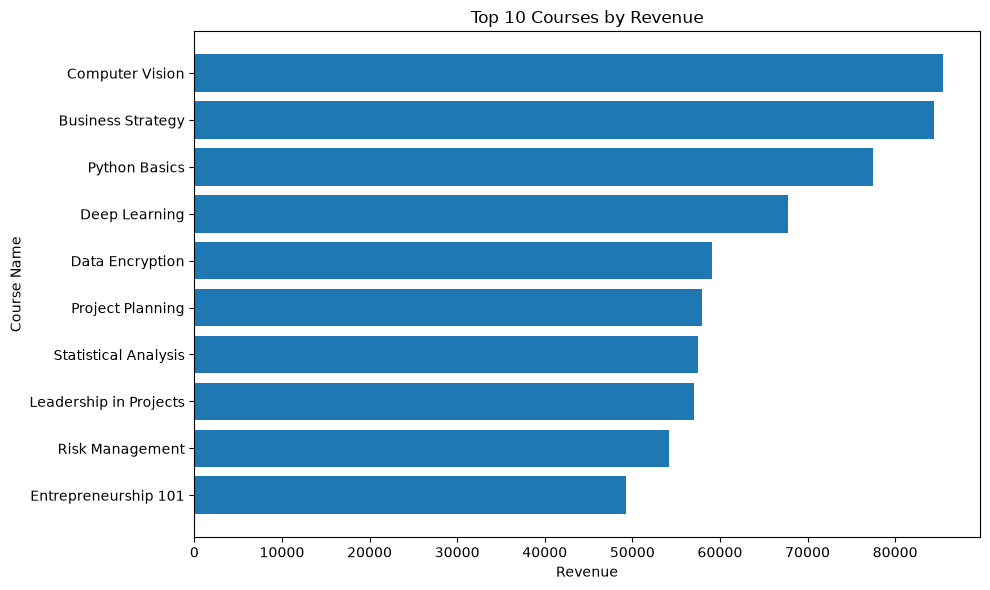

In [42]:
top10_revenue = top_courses_revenue.sort_values(
    "CourseRevenue"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_revenue["CourseName"],
    top10_revenue["CourseRevenue"]
)

plt.title("Top 10 Courses by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Course Name")
plt.tight_layout()
plt.show()

## Price vs Enrollment

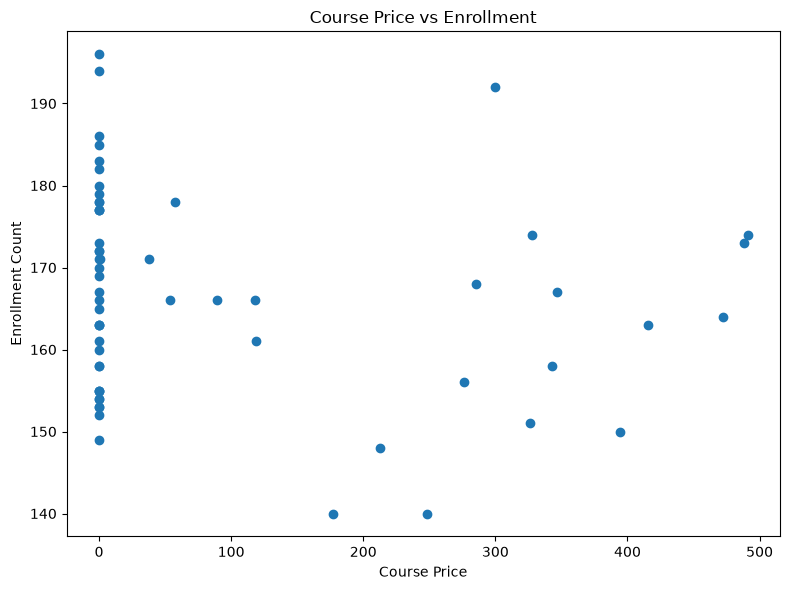

In [43]:
plt.figure(figsize=(8, 6))

plt.scatter(
    courses_eda["CoursePrice"],
    courses_eda["EnrollmentCount"]
)

plt.title("Course Price vs Enrollment")
plt.xlabel("Course Price")
plt.ylabel("Enrollment Count")
plt.tight_layout()
plt.show()

In [44]:
courses_eda[
    ["CoursePrice", "EnrollmentCount"]
].corr()

,CoursePrice,EnrollmentCount
CoursePrice,1.000000,-0.163356
EnrollmentCount,-0.163356,1.000000


## Rating vs Enrollment

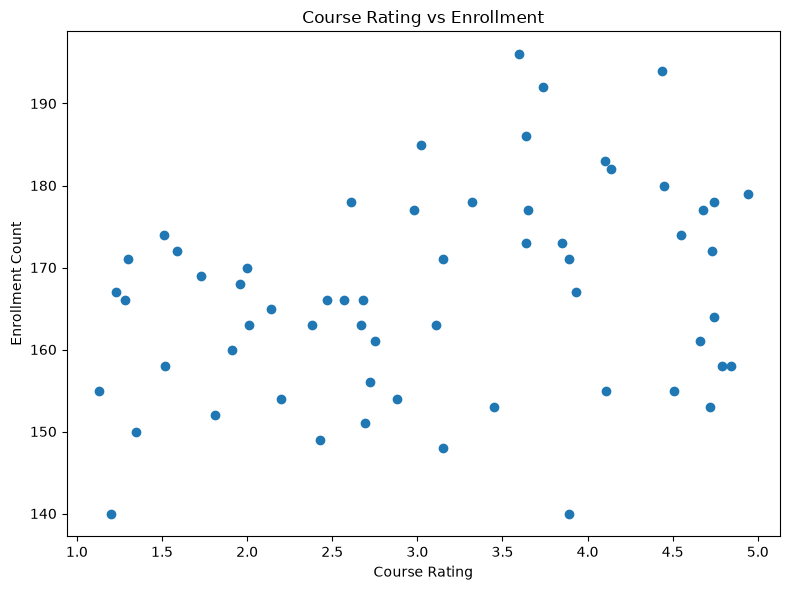

In [45]:
plt.figure(figsize=(8, 6))

plt.scatter(
    courses_eda["CourseRating"],
    courses_eda["EnrollmentCount"]
)

plt.title("Course Rating vs Enrollment")
plt.xlabel("Course Rating")
plt.ylabel("Enrollment Count")
plt.tight_layout()
plt.show()

In [46]:
courses_eda[
    ["CourseRating", "EnrollmentCount"]
].corr()

,CourseRating,EnrollmentCount
CourseRating,1.00000,0.29401
EnrollmentCount,0.29401,1.00000


## Course Duration vs Enrollment

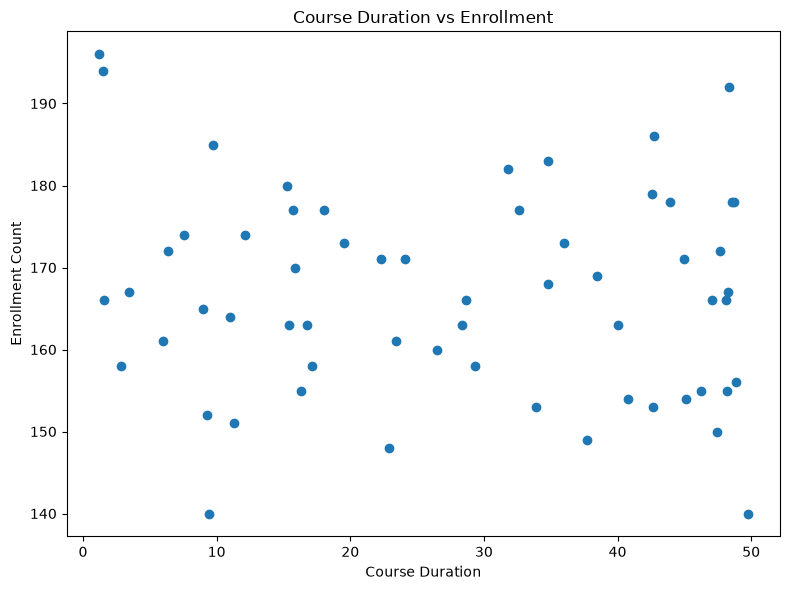

In [47]:
plt.figure(figsize=(8, 6))

plt.scatter(
    courses_eda["CourseDuration"],
    courses_eda["EnrollmentCount"]
)

plt.title("Course Duration vs Enrollment")
plt.xlabel("Course Duration")
plt.ylabel("Enrollment Count")
plt.tight_layout()
plt.show()

In [48]:
courses_eda[
    ["CourseDuration", "EnrollmentCount"]
].corr()

,CourseDuration,EnrollmentCount
CourseDuration,1.000000,-0.103414
EnrollmentCount,-0.103414,1.000000


## Price vs Revenue

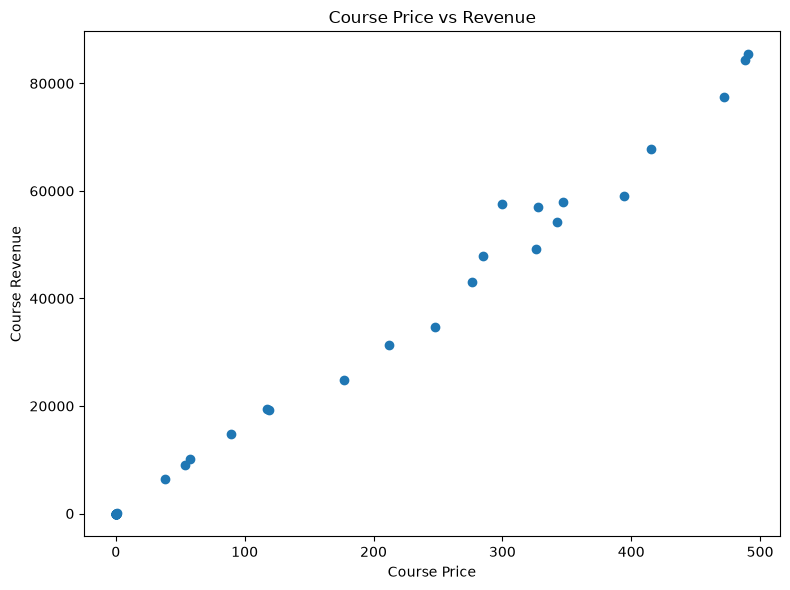

In [49]:
plt.figure(figsize=(8, 6))

plt.scatter(
    courses_eda["CoursePrice"],
    courses_eda["CourseRevenue"]
)

plt.title("Course Price vs Revenue")
plt.xlabel("Course Price")
plt.ylabel("Course Revenue")
plt.tight_layout()
plt.show()

In [50]:
courses_eda[
    ["CoursePrice", "CourseRevenue"]
].corr()

,CoursePrice,CourseRevenue
CoursePrice,1.000000,0.996722
CourseRevenue,0.996722,1.000000


## Enrollment dsitribution

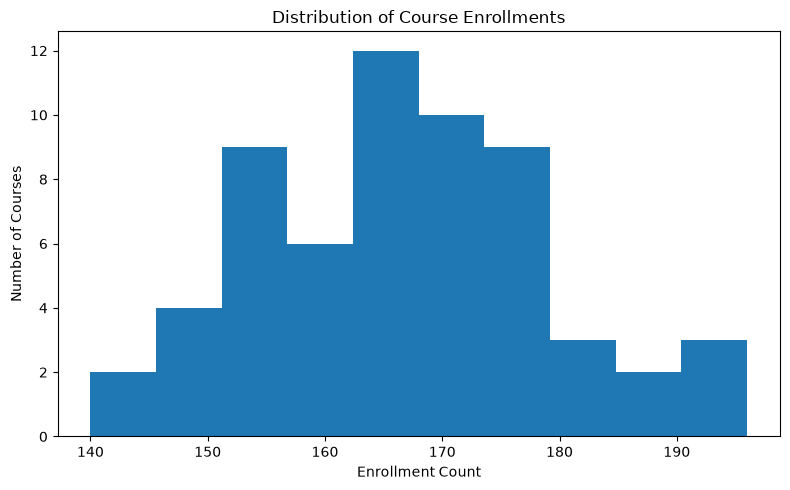

In [51]:

plt.figure(figsize=(8, 5))

plt.hist(
    courses_eda["EnrollmentCount"],
    bins=10
)

plt.title("Distribution of Course Enrollments")
plt.xlabel("Enrollment Count")
plt.ylabel("Number of Courses")
plt.tight_layout()
plt.show()

In [52]:
courses_eda["EnrollmentCount"].describe()

count     60.000000
mean     166.666667
std       12.523424
min      140.000000
25%      157.500000
50%      166.000000
75%      174.750000
max      196.000000
Name: EnrollmentCount, dtype: float64

## Revenue Distribution

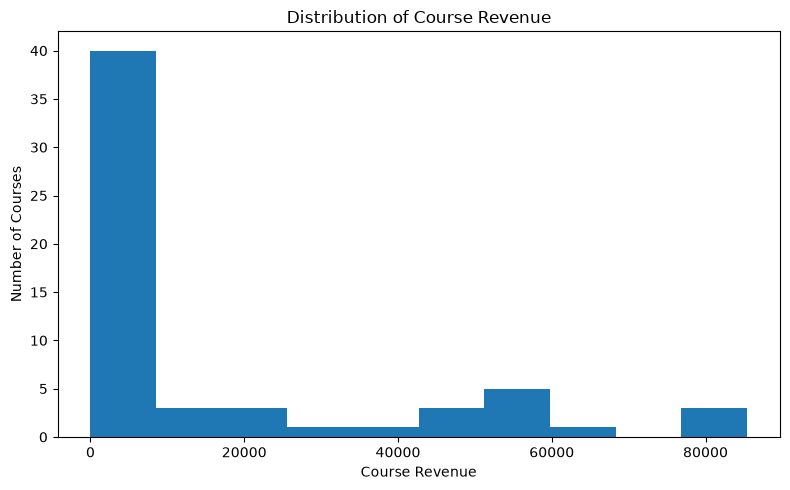

In [53]:
plt.figure(figsize=(8, 5))

plt.hist(
    courses_eda["CourseRevenue"],
    bins=10
)

plt.title("Distribution of Course Revenue")
plt.xlabel("Course Revenue")
plt.ylabel("Number of Courses")
plt.tight_layout()
plt.show()

In [54]:
courses_eda["CourseRevenue"].describe()

count       60.000000
mean     15188.724500
std      25409.721911
min          0.000000
25%          0.000000
50%          0.000000
75%      20858.060000
max      85416.600000
Name: CourseRevenue, dtype: float64

## Correlation analysis

In [55]:
numeric_columns = [
    "CoursePrice",
    "CourseDuration",
    "CourseRating",
    "EnrollmentCount",
    "CourseRevenue"
]

correlation_matrix = courses_eda[numeric_columns].corr()

print(correlation_matrix)

                 CoursePrice  CourseDuration  CourseRating  EnrollmentCount  \
CoursePrice         1.000000       -0.096051     -0.031973        -0.163356   
CourseDuration     -0.096051        1.000000      0.209411        -0.103414   
CourseRating       -0.031973        0.209411      1.000000         0.294010   
EnrollmentCount    -0.163356       -0.103414      0.294010         1.000000   
CourseRevenue       0.996722       -0.094198     -0.018298        -0.116611   

                 CourseRevenue  
CoursePrice           0.996722  
CourseDuration       -0.094198  
CourseRating         -0.018298  
EnrollmentCount      -0.116611  
CourseRevenue         1.000000  


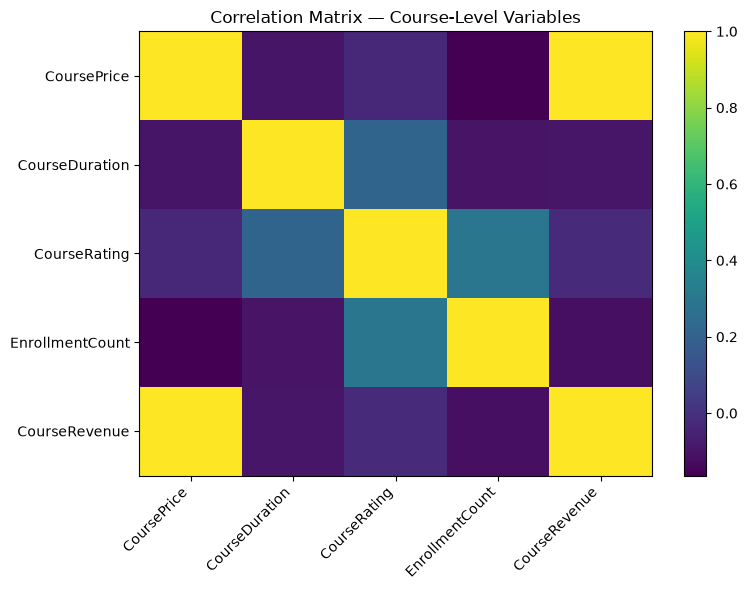

In [56]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix — Course-Level Variables")

plt.tight_layout()
plt.show()

## Identify potential outliers

In [57]:
Q1 = courses_eda["EnrollmentCount"].quantile(0.25)
Q3 = courses_eda["EnrollmentCount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

enrollment_outliers = courses_eda[
    (courses_eda["EnrollmentCount"] < lower_bound) |
    (courses_eda["EnrollmentCount"] > upper_bound)
]

enrollment_outliers

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,EnrollmentCount,CourseRevenue


In [58]:
Q1 = courses_eda["CourseRevenue"].quantile(0.25)
Q3 = courses_eda["CourseRevenue"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

revenue_outliers = courses_eda[
    (courses_eda["CourseRevenue"] < lower_bound) |
    (courses_eda["CourseRevenue"] > upper_bound)
]

revenue_outliers

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,EnrollmentCount,CourseRevenue
7,CR00025,Statistical Analysis,Data Science,Paid,Beginner,299.57,48.32,3.74,192,57517.44
14,CR00040,Leadership in Projects,Project Management,Paid,Beginner,327.99,12.13,1.51,174,57070.26
16,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74,164,77453.92
40,CR00050,Computer Vision,Artificial Intelligence,Paid,Beginner,490.90,7.55,4.55,174,85416.60
45,CR00012,Business Strategy,Business,Paid,Advanced,487.92,36.01,3.64,173,84410.16
48,CR00049,Deep Learning,Artificial Intelligence,Paid,Intermediate,415.51,28.33,3.11,163,67728.13
52,CR00034,Data Encryption,Cybersecurity,Paid,Intermediate,394.26,47.44,1.35,150,59139.00
55,CR00039,Project Planning,Project Management,Paid,Advanced,346.71,3.42,1.23,167,57900.57
58,CR00038,Risk Management,Project Management,Paid,Intermediate,342.61,17.14,4.84,158,54132.38


## Create a useful Course Performance table

In [59]:
course_performance = courses_eda[
    [
        "CourseID",
        "CourseName",
        "CourseCategory",
        "CourseType",
        "CourseLevel",
        "CoursePrice",
        "CourseDuration",
        "CourseRating",
        "EnrollmentCount",
        "CourseRevenue"
    ]
].copy()

In [60]:
course_performance = course_performance.sort_values(
    "EnrollmentCount",
    ascending=False
)

In [61]:
course_performance.head(10)

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,EnrollmentCount,CourseRevenue
19,CR00021,Data Analysis with Python,Data Science,Free,Intermediate,0.00,1.20,3.60,196,0.00
25,CR00058,Social Media Strategy,Digital Marketing,Free,Beginner,0.00,1.46,4.44,194,0.00
7,CR00025,Statistical Analysis,Data Science,Paid,Beginner,299.57,48.32,3.74,192,57517.44
3,CR00048,AI Ethics,Artificial Intelligence,Free,Beginner,0.00,42.70,3.64,186,0.00
35,CR00023,Machine Learning Fundamentals,Data Science,Free,Intermediate,0.00,9.71,3.02,185,0.00
5,CR00042,Investment Strategies,Finance,Free,Intermediate,0.00,34.83,4.10,183,0.00
21,CR00043,Corporate Finance,Finance,Free,Beginner,0.00,31.77,4.14,182,0.00
18,CR00010,3D Modeling,Design,Free,Advanced,0.00,15.29,4.45,180,0.00
23,CR00035,Cyber Threat Intelligence,Cybersecurity,Free,Beginner,0.00,42.59,4.94,179,0.00
37,CR00007,UI/UX Design,Design,Free,Advanced,0.00,48.68,2.61,178,0.00


## Saving EDA work

In [62]:
from pathlib import Path

eda_folder = Path(
    r"D:\Data Analytics Project\EduPro_Predictive_Modeling\data\eda_data"
)

eda_folder.mkdir(
    parents=True,
    exist_ok=True
)

In [63]:
eda_file_path = eda_folder / "EduPro_Course_EDA.xlsx"

In [64]:
course_performance.to_excel(
    eda_file_path,
    sheet_name="Course_Performance",
    index=False
)

In [65]:
print(f"Course EDA output saved at:\n{eda_file_path}")

Course EDA output saved at:
D:\Data Analytics Project\EduPro_Predictive_Modeling\data\eda_data\EduPro_Course_EDA.xlsx


## Final Validation

In [66]:
print("DAY 4 COURSE EDA VALIDATION")
print("----------------------------")

print("Unique Courses:", courses_eda["CourseID"].nunique())
print("Course EDA Rows:", courses_eda.shape[0])
print("Course EDA Columns:", courses_eda.shape[1])
print("Missing Values:", courses_eda.isnull().sum().sum())
print(
    "Duplicate CourseIDs:",
    courses_eda["CourseID"].duplicated().sum()
)
print(
    "Total Enrollments:",
    courses_eda["EnrollmentCount"].sum()
)
print(
    "Total Revenue:",
    courses_eda["CourseRevenue"].sum()
)

DAY 4 COURSE EDA VALIDATION
----------------------------
Unique Courses: 60
Course EDA Rows: 60
Course EDA Columns: 10
Missing Values: 0
Duplicate CourseIDs: 0
Total Enrollments: 10000
Total Revenue: 911323.47
